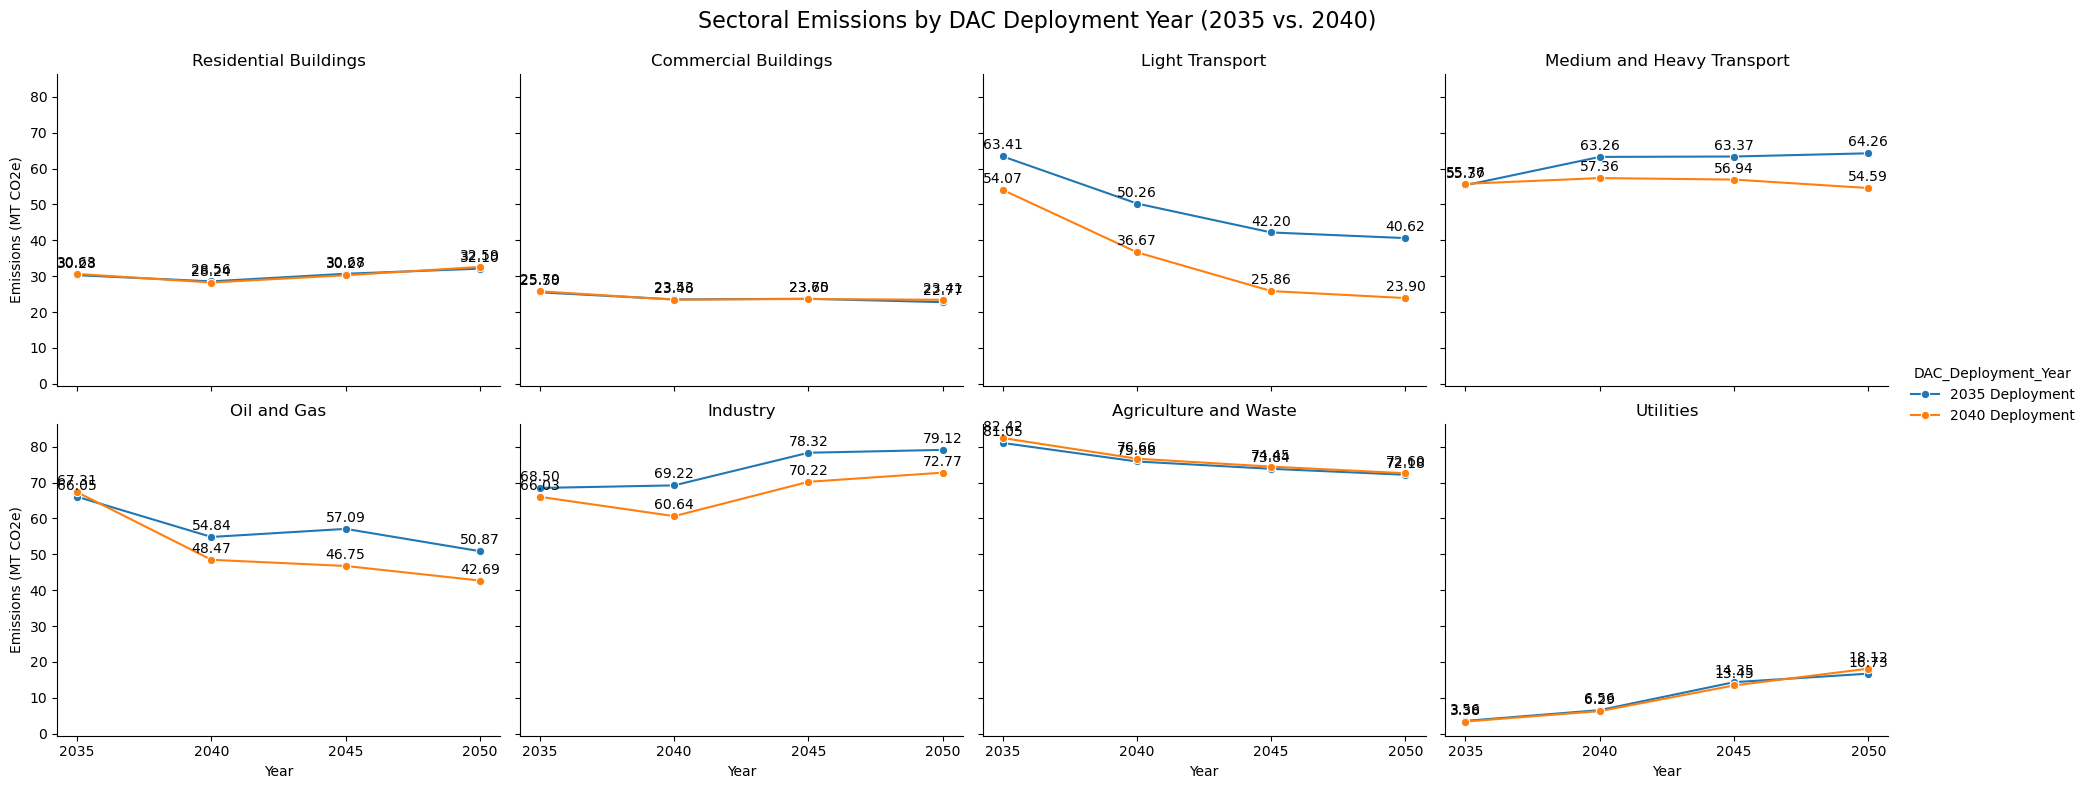

In [1]:
"""
Created on Thu Aug 29 20:40:40 2024

@author: fyabdulla
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Hard-coded data
data = {
    'Year': [2035, 2040, 2045, 2050] * 16,  # Repeated 4 times for each sector, for both 2035 and 2040 deployment years
    'Sector': (
        ['Residential Buildings'] * 4 + ['Commercial Buildings'] * 4 + 
        ['Light Transport'] * 4 + ['Medium and Heavy Transport'] * 4 +
        ['Oil and Gas'] * 4 + ['Industry'] * 4 + 
        ['Agriculture and Waste'] * 4 + ['Utilities'] * 4
    ) * 2,  # Repeated for both 2035 and 2040 deployment years
    'DAC_Deployment_Year': ['2035 Deployment'] * 32 + ['2040 Deployment'] * 32,  # Repeated for 2035 and 2040
    'Emissions': (
        [30.282, 28.560, 30.681, 32.105] + [25.496, 23.533, 23.703, 22.766] + 
        [63.406, 50.262, 42.198, 40.622] + [55.371, 63.258, 63.370, 64.264] +
        [66.050, 54.840, 57.094, 50.870] + [68.505, 69.225, 78.322, 79.118] +
        [81.051, 75.883, 73.839, 72.184] + [3.562, 6.560, 14.352, 16.727] +
        [30.626, 28.240, 30.267, 32.588] + [25.792, 23.456, 23.651, 23.415] + 
        [54.067, 36.666, 25.855, 23.898] + [55.756, 57.357, 56.938, 54.587] +
        [67.312, 48.473, 46.752, 42.691] + [66.025, 60.643, 70.215, 72.772] +
        [82.422, 76.662, 74.455, 72.602] + [3.377, 6.285, 13.445, 18.118]
    )  # Emissions data for both 2035 and 2040
}

# Create a DataFrame
df_sensitivity = pd.DataFrame(data)

# Facet Grid Plot with customized x-axis ticks and titles
g = sns.FacetGrid(df_sensitivity, col="Sector", hue="DAC_Deployment_Year", col_wrap=4, height=4, aspect=1.2)

# Map the line plot
g.map(sns.lineplot, "Year", "Emissions", marker="o").add_legend()

# Add data labels for each point
for ax in g.axes.flat:
    for line in ax.lines:
        for x, y in zip(line.get_xdata(), line.get_ydata()):
            ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 5), ha='center')

# Set specific x-axis ticks
for ax in g.axes.flat:
    ax.set_xticks([2035, 2040, 2045, 2050])  # Set the ticks to the desired years
    ax.set_xticklabels(['2035', '2040', '2045', '2050'])  # Set the labels to match

# Customize the subplot titles to only show the sector name
for ax in g.axes.flat:
    ax.set_title(ax.get_title().split('=')[1].strip().replace("'", ""))

# Set axis labels and adjust the layout
g.set_axis_labels("Year", "Emissions (MT CO2e)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Sectoral Emissions by DAC Deployment Year (2035 vs. 2040)', fontsize=16)
plt.show()


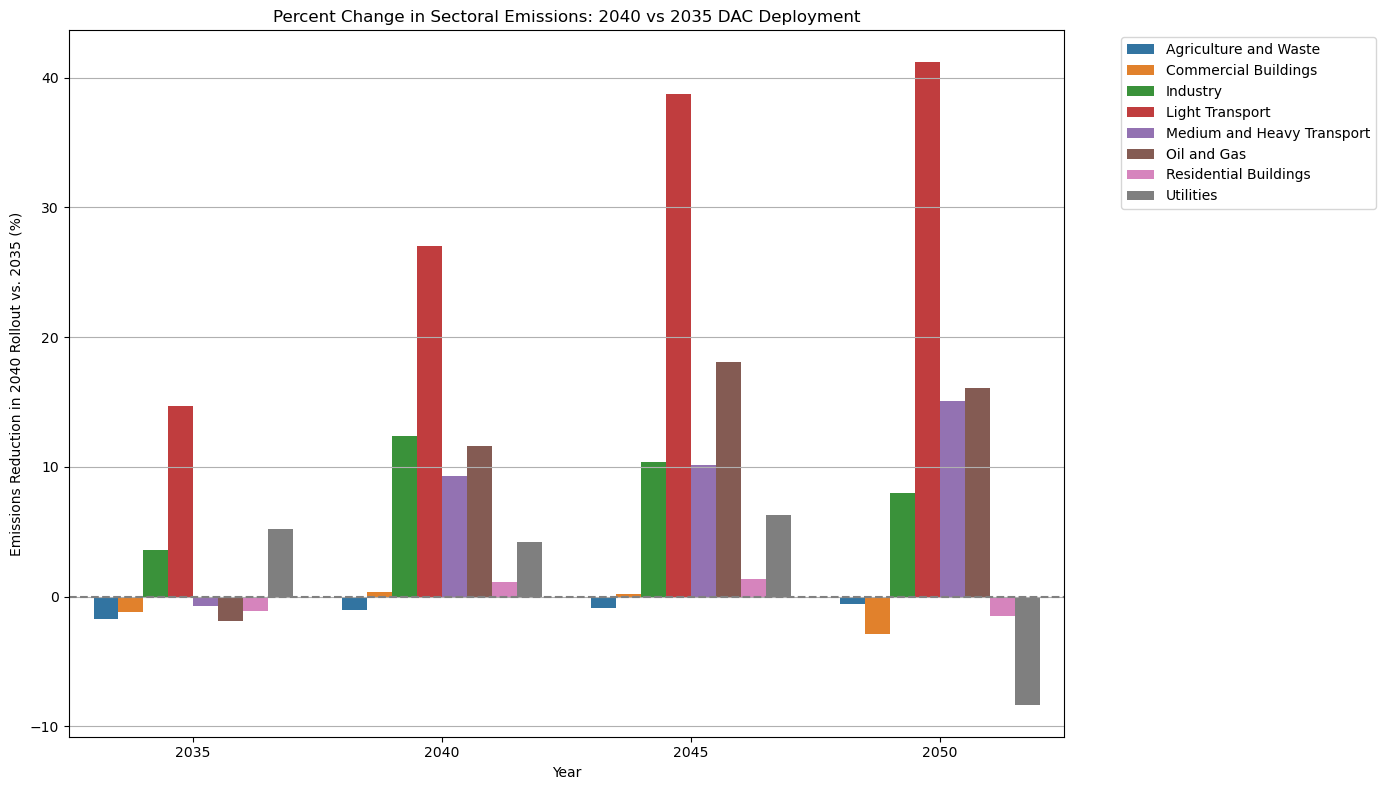

In [ ]:
# Pivot the data to get emissions by Sector, Year, and DAC_Deployment_Year
pivot_df = df_sensitivity.pivot_table(
    index=["Sector", "Year"],
    columns="DAC_Deployment_Year",
    values="Emissions"
).reset_index()

# Calculate percent change: (2035 - 2040) / 2035 * 100 → positive means a drop in emissions in 2040 rollout
pivot_df["Percent_Change"] = (
    (pivot_df["2035 Deployment"] - pivot_df["2040 Deployment"]) /
    pivot_df["2035 Deployment"]
) * 100

# Plot the bar chart
plt.figure(figsize=(14, 8))
sns.barplot(
    data=pivot_df,
    x="Year",
    y="Percent_Change",
    hue="Sector"
)

plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("Emissions Reduction in 2040 Rollout vs. 2035 (%)")
plt.title("Percent Change in Sectoral Emissions: 2040 vs 2035 DAC Deployment")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
